In [31]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

from config import (
    TEST_FILE, TRAIN_FILE, TFIDF_MODEL_FILE, KMEANS_MODEL_FILE,
    JUNK_CLF_MODEL_FILE, CLUSTER_LABELS_FILE, FIGURES_DIR,
)
from utils.preprocessor import preprocess_to_string

# 加载所有模型
vectorizer = joblib.load(str(TFIDF_MODEL_FILE))
kmeans = joblib.load(str(KMEANS_MODEL_FILE))
junk_clf = joblib.load(str(JUNK_CLF_MODEL_FILE))
with open(str(CLUSTER_LABELS_FILE), "r", encoding="utf-8") as f:
    cluster_labels_map = json.load(f)

# 加载测试集
test_df = pd.read_csv(str(TEST_FILE), encoding="utf-8-sig")
train_df = pd.read_csv(str(TRAIN_FILE), encoding="utf-8-sig")

print(f"模型加载完成")
print(f"  TF-IDF 词表大小: {len(vectorizer.get_feature_names_out())}")
print(f"  K-Means K={kmeans.n_clusters}")
print(f"  测试集: {len(test_df)} 条")

# 完整推理流程演示
demo_texts = [
    "React组件之间怎么传递数据？props和context应该怎么选择？",
    "MySQL索引优化，explain分析慢查询的执行计划",
    "今天加班到凌晨两点，好累啊不想上班了",
    "有没有人一起打王者荣耀，星耀段位求带",
    "用Docker Compose编排多容器应用，一键启动整个开发环境",
]

print(f"\n完整推理流程演示:")
print("=" * 70)
for text in demo_texts:
    processed = preprocess_to_string(text)
    vec = vectorizer.transform([processed])
    is_junk = junk_clf.predict(vec)[0]
    cluster_id = kmeans.predict(vec)[0]
    cluster_info = cluster_labels_map.get(str(cluster_id), {})
    tags = cluster_info.get("tags", [])
    label = "垃圾" if is_junk == 1 else "技术"
    print(f"  原文: {text[:50]}")
    print(f"  判定: {label} | 簇{cluster_id}({cluster_info.get('name','')}) | 标签: {tags}")
    print()

模型加载完成
  TF-IDF 词表大小: 5000
  K-Means K=10
  测试集: 1546 条

完整推理流程演示:
  原文: React组件之间怎么传递数据？props和context应该怎么选择？
  判定: 技术 | 簇8(编程开发) | 标签: ['AI/ML', 'React', 'Java', '数据库', 'DevOps']

  原文: MySQL索引优化，explain分析慢查询的执行计划
  判定: 技术 | 簇8(编程开发) | 标签: ['AI/ML', 'React', 'Java', '数据库', 'DevOps']

  原文: 今天加班到凌晨两点，好累啊不想上班了
  判定: 垃圾 | 簇2(生活日常) | 标签: ['非技术']

  原文: 有没有人一起打王者荣耀，星耀段位求带
  判定: 垃圾 | 簇5(大众闲聊) | 标签: ['非技术']

  原文: 用Docker Compose编排多容器应用，一键启动整个开发环境
  判定: 技术 | 簇8(编程开发) | 标签: ['AI/ML', 'React', 'Java', '数据库', 'DevOps']



技术帖测试集: 511 条

原始类别 vs 预测簇 交叉表:
predicted_name  号召互动  大众闲聊  情感社交  推荐咨询  生活日常  电脑技术  综合闲聊  编程开发  All
category                                                           
AI/ML              1     7     0     0     1     0     1    13   23
C/C++              0     1     0     0     0     0     0     0    1
CSS                0     4     0     0     0     0     0     3    7
DevOps             1    14     0     0     3     2     2     5   27
Git                0     1     0     0     0     0     0     0    1
Java               0     0     0     0     0     1     0     3    4
JavaScript         0     3     0     0     0     0     0     4    7
Linux              0     0     0     0     0     1     0     0    1
Node.js            0     1     0     0     0     0     0     2    3
Python             0     2     0     0     0     0     0     3    5
React              0     3     0     0     0     0     0     9   12
TypeScript         0     1     0     0     0     0     0     0    1
Vue             

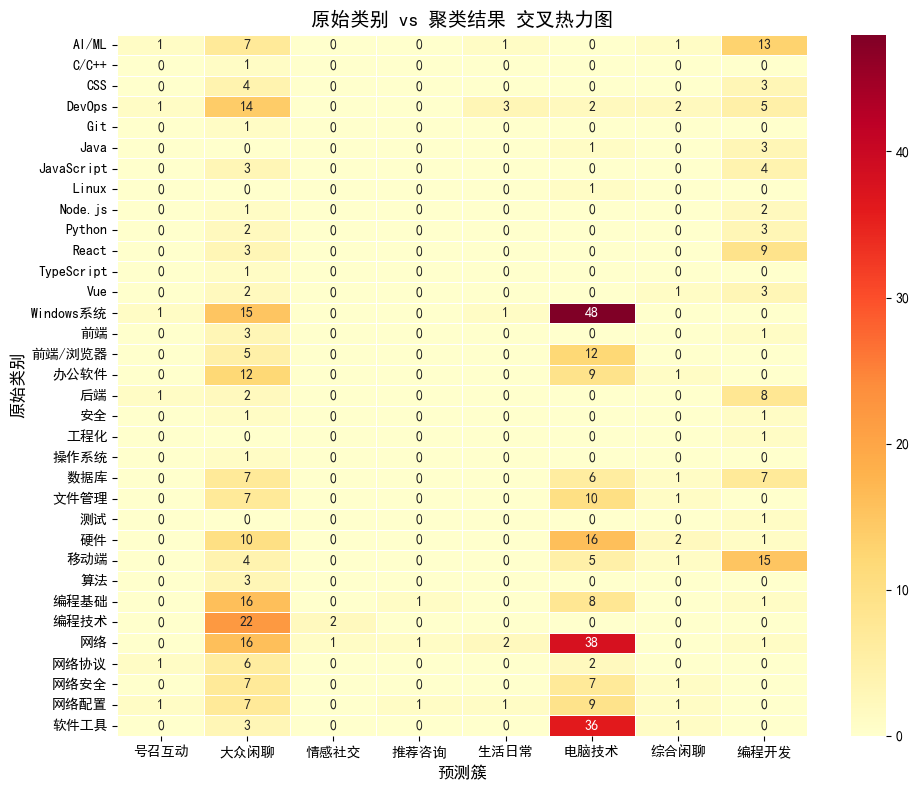

In [32]:
# 对测试集中的技术帖做聚类分析
tech_test = test_df[test_df["is_junk"] == 0].copy()
tech_test_texts = tech_test["processed_text"].fillna("").astype(str)
tech_test_vecs = vectorizer.transform(tech_test_texts)
tech_test["predicted_cluster"] = kmeans.predict(tech_test_vecs)
tech_test["predicted_name"] = tech_test["predicted_cluster"].apply(
    lambda c: cluster_labels_map.get(str(c), {}).get("name", "未知")
)

print(f"技术帖测试集: {len(tech_test)} 条")
print(f"\n原始类别 vs 预测簇 交叉表:")
cross = pd.crosstab(
    tech_test["category"].fillna("未知"),
    tech_test["predicted_name"],
    margins=True,
)
print(cross.to_string())

# 绘制热力图
cross_no_margin = cross.iloc[:-1, :-1]  # 去掉 All 行列
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cross_no_margin, annot=True, fmt="d", cmap="YlOrRd",
    ax=ax, linewidths=0.5,
)
ax.set_title("原始类别 vs 聚类结果 交叉热力图", fontsize=14)
ax.set_xlabel("预测簇", fontsize=12)
ax.set_ylabel("原始类别", fontsize=12)
plt.tight_layout()

os.makedirs(str(FIGURES_DIR), exist_ok=True)
fig.savefig(str(FIGURES_DIR / "category_vs_cluster.png"), dpi=200)
print(f"\n交叉热力图已保存")
plt.show()

图1 各簇帖子数量柱状图 ✓


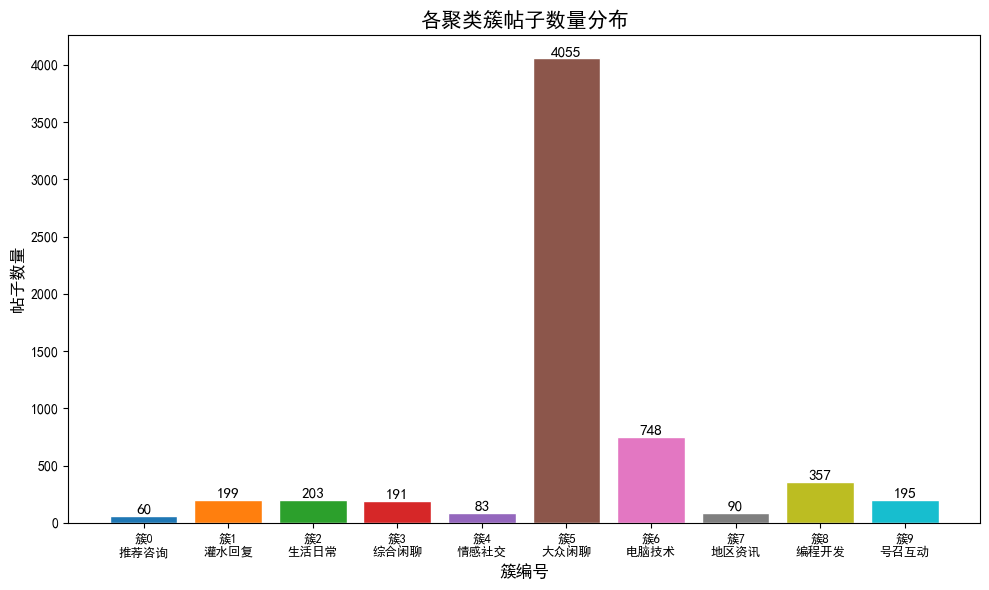

In [33]:
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    classification_report, confusion_matrix, f1_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 准备训练集数据
train_texts = train_df["processed_text"].fillna("").astype(str)
X_train = vectorizer.transform(train_texts)
train_clusters = kmeans.predict(X_train)

# ── 图1：各簇帖子数量柱状图 ──
fig, ax = plt.subplots(figsize=(10, 6))
cluster_counts = pd.Series(train_clusters).value_counts().sort_index()
colors = plt.cm.tab10(np.arange(len(cluster_counts)))
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor="white")
for bar, count in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha="center", fontsize=11, fontweight="bold")

# 加上簇名称
xlabels = [f"簇{i}\n{cluster_labels_map.get(str(i), {}).get('name', '')}" for i in cluster_counts.index]
ax.set_xticks(cluster_counts.index)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_title("各聚类簇帖子数量分布", fontsize=15)
ax.set_xlabel("簇编号", fontsize=12)
ax.set_ylabel("帖子数量", fontsize=12)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / "cluster_distribution.png"), dpi=200)
print("图1 各簇帖子数量柱状图 ✓")
plt.show()

In [34]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


IndexError: index 8 is out of bounds for axis 0 with size 8

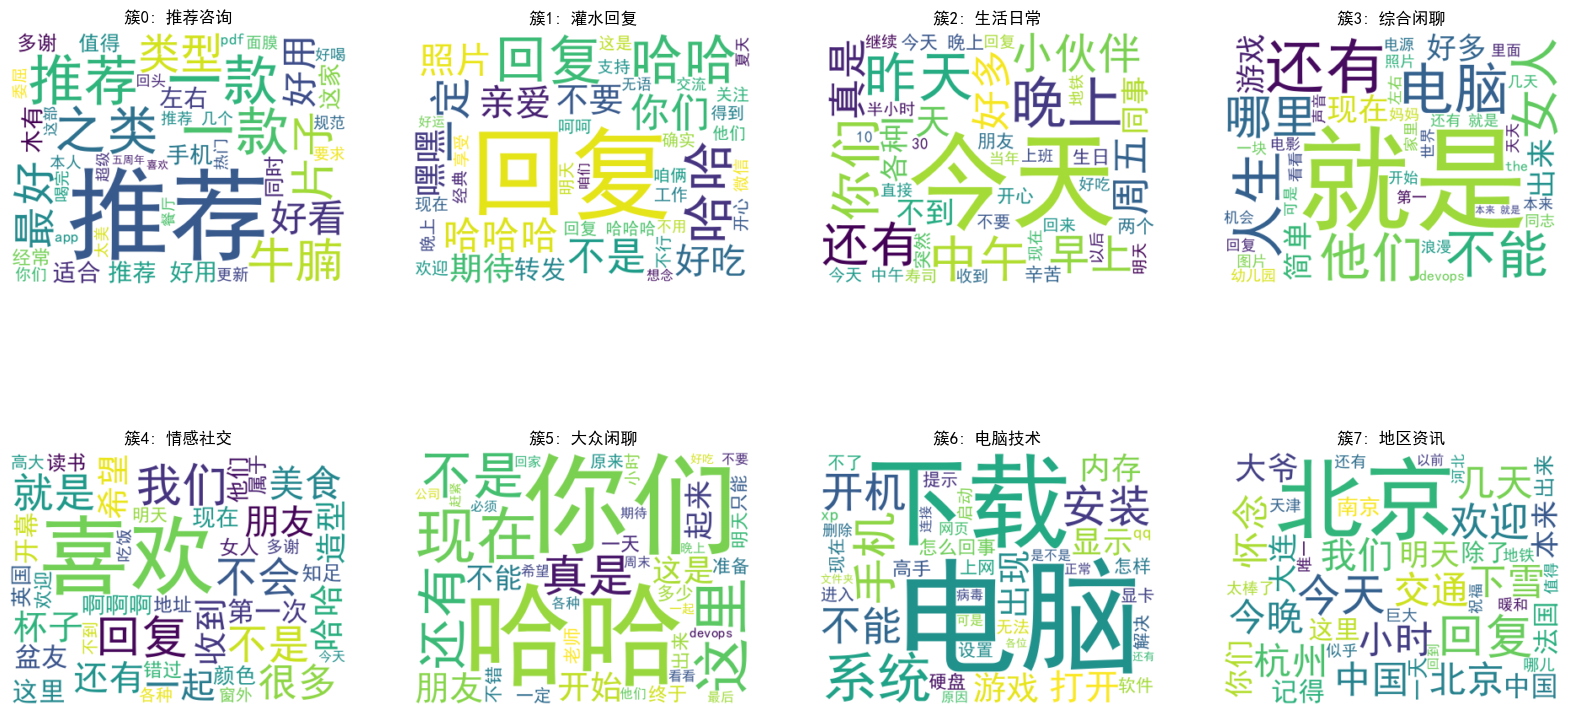

In [35]:
# ── 图2：词云图（每个簇一张）──
try:
    from wordcloud import WordCloud

    # Windows 中文字体路径
    font_path = "C:/Windows/Fonts/simhei.ttf"
    if not os.path.exists(font_path):
        font_path = "C:/Windows/Fonts/msyh.ttc"
    if not os.path.exists(font_path):
        font_path = None  # 回退到默认

    feature_names = vectorizer.get_feature_names_out()
    centroids = kmeans.cluster_centers_
    n_clusters = kmeans.n_clusters

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for c in range(n_clusters):
        # 取质心向量中权重最高的 50 个词
        top_idx = centroids[c].argsort()[-50:][::-1]
        word_freq = {feature_names[i]: centroids[c][i] for i in top_idx if centroids[c][i] > 0}

        if word_freq:
            wc_kwargs = dict(
                width=400, height=300,
                background_color="white",
                max_words=40,
                colormap="viridis",
            )
            if font_path:
                wc_kwargs["font_path"] = font_path

            wc = WordCloud(**wc_kwargs).generate_from_frequencies(word_freq)
            axes[c].imshow(wc, interpolation="bilinear")

        cluster_name = cluster_labels_map.get(str(c), {}).get("name", f"簇{c}")
        axes[c].set_title(f"簇{c}: {cluster_name}", fontsize=12)
        axes[c].axis("off")

    # 隐藏多余的子图
    for i in range(n_clusters, len(axes)):
        axes[i].axis("off")

    plt.suptitle("各聚类簇关键词词云图", fontsize=16, y=1.02)
    plt.tight_layout()
    fig.savefig(str(FIGURES_DIR / "cluster_wordclouds.png"), dpi=200, bbox_inches="tight")
    print("图2 词云图 ✓")
    plt.show()
except ImportError:
    print("wordcloud 未安装，跳过词云图。运行 pip install wordcloud 后重试。")

图3 PCA 双视图 ✓


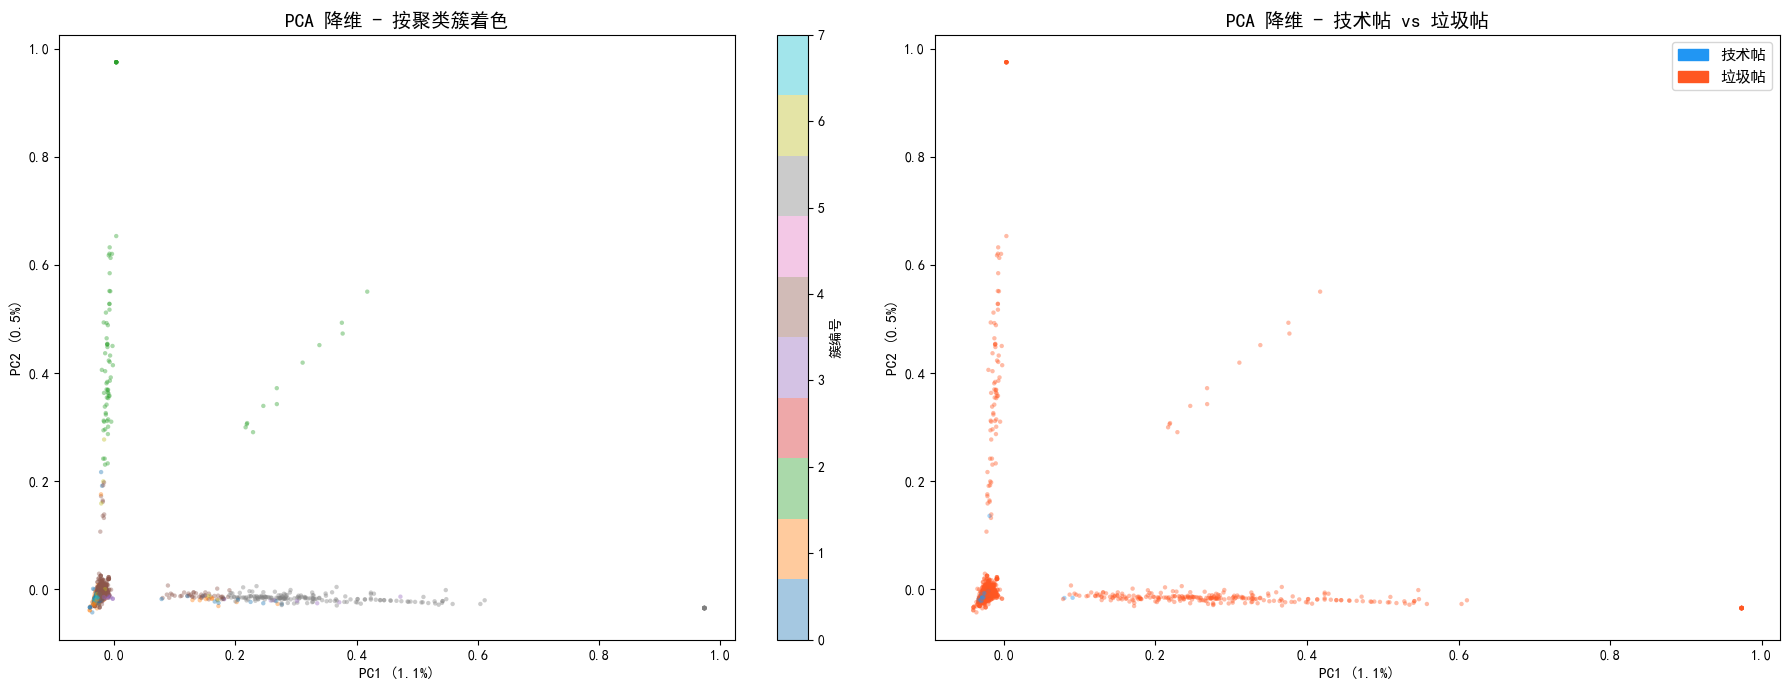

In [ ]:
# ── 图3：PCA 聚类散点图（区分技术/垃圾）──
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(X_train.toarray())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 左图：按聚类簇着色
scatter1 = axes[0].scatter(
    coords_pca[:, 0], coords_pca[:, 1],
    c=train_clusters, cmap="tab10", alpha=0.4, s=10, edgecolors="none",
)
axes[0].set_title("PCA 降维 - 按聚类簇着色", fontsize=14)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
plt.colorbar(scatter1, ax=axes[0], label="簇编号")

# 右图：按技术/垃圾着色
is_junk = train_df["is_junk"].values
colors_junk = ["#2196F3" if j == 0 else "#FF5722" for j in is_junk]
axes[1].scatter(
    coords_pca[:, 0], coords_pca[:, 1],
    c=colors_junk, alpha=0.4, s=10, edgecolors="none",
)
axes[1].set_title("PCA 降维 - 技术帖 vs 垃圾帖", fontsize=14)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
# 图例
from matplotlib.patches import Patch
axes[1].legend(
    handles=[Patch(color="#2196F3", label="技术帖"), Patch(color="#FF5722", label="垃圾帖")],
    fontsize=11,
)

plt.tight_layout()
fig.savefig(str(FIGURES_DIR / "pca_dual_view.png"), dpi=200)
print("图3 PCA 双视图 ✓")
plt.show()

图4 t-SNE 双视图 ✓


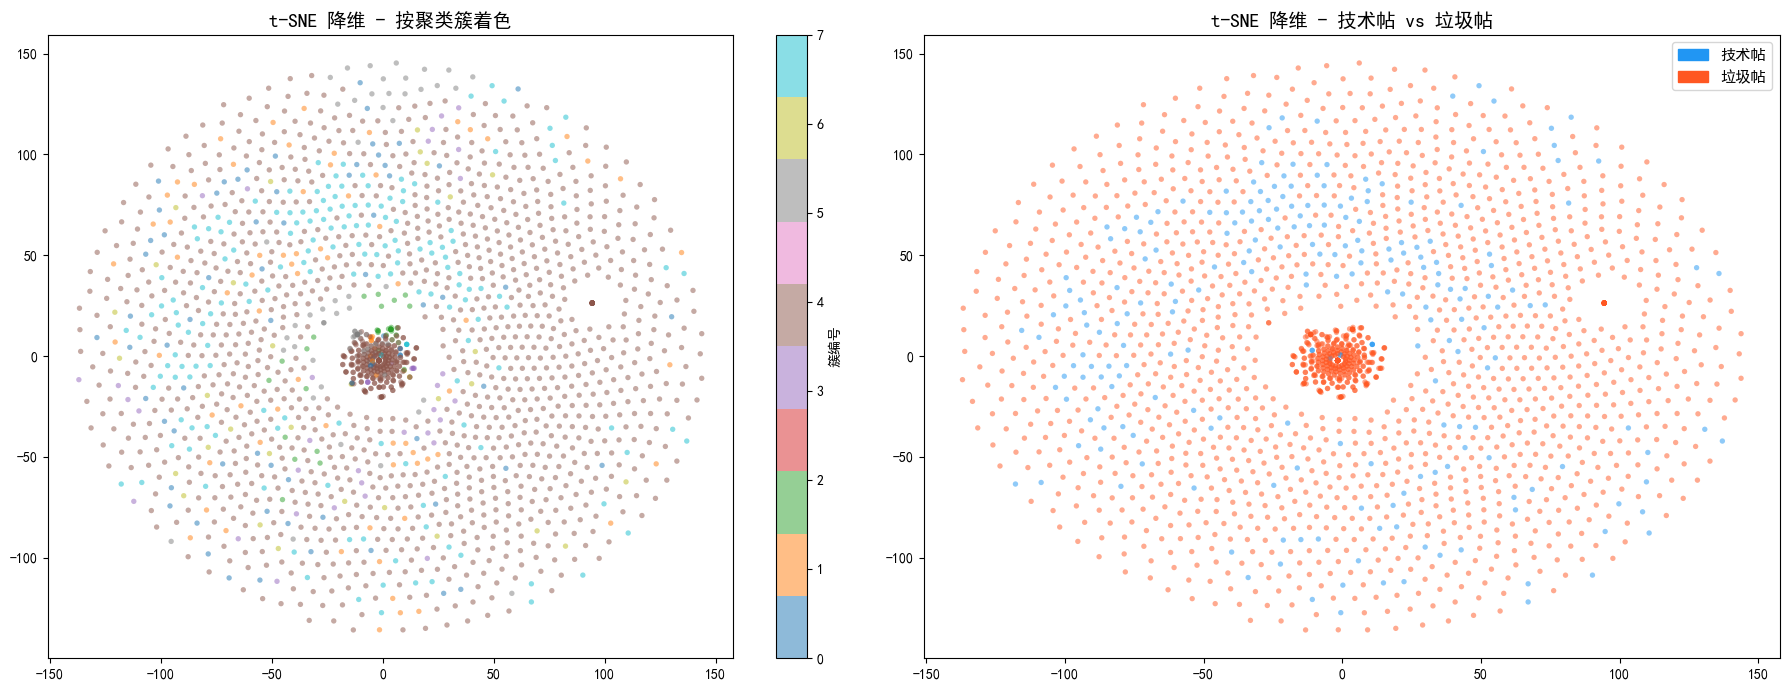

In [ ]:
# ── 图4：t-SNE 散点图（技术 vs 垃圾）──
# t-SNE 数据量大时很慢，抽样 2000 条
sample_n = min(2000, len(train_df))
np.random.seed(42)
sample_idx = np.random.choice(len(train_df), size=sample_n, replace=False)

X_sample = X_train[sample_idx]
clusters_sample = train_clusters[sample_idx]
junk_sample = train_df["is_junk"].values[sample_idx]

perp = min(30, sample_n - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perp, n_iter=1000)
coords_tsne = tsne.fit_transform(X_sample.toarray())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(
    coords_tsne[:, 0], coords_tsne[:, 1],
    c=clusters_sample, cmap="tab10", alpha=0.5, s=15, edgecolors="none",
)
axes[0].set_title("t-SNE 降维 - 按聚类簇着色", fontsize=14)
plt.colorbar(scatter1, ax=axes[0], label="簇编号")

colors_junk_s = ["#2196F3" if j == 0 else "#FF5722" for j in junk_sample]
axes[1].scatter(
    coords_tsne[:, 0], coords_tsne[:, 1],
    c=colors_junk_s, alpha=0.5, s=15, edgecolors="none",
)
axes[1].set_title("t-SNE 降维 - 技术帖 vs 垃圾帖", fontsize=14)
axes[1].legend(
    handles=[Patch(color="#2196F3", label="技术帖"), Patch(color="#FF5722", label="垃圾帖")],
    fontsize=11,
)

plt.tight_layout()
fig.savefig(str(FIGURES_DIR / "tsne_dual_view.png"), dpi=200)
print("图4 t-SNE 双视图 ✓")
plt.show()

图5 混淆矩阵 ✓


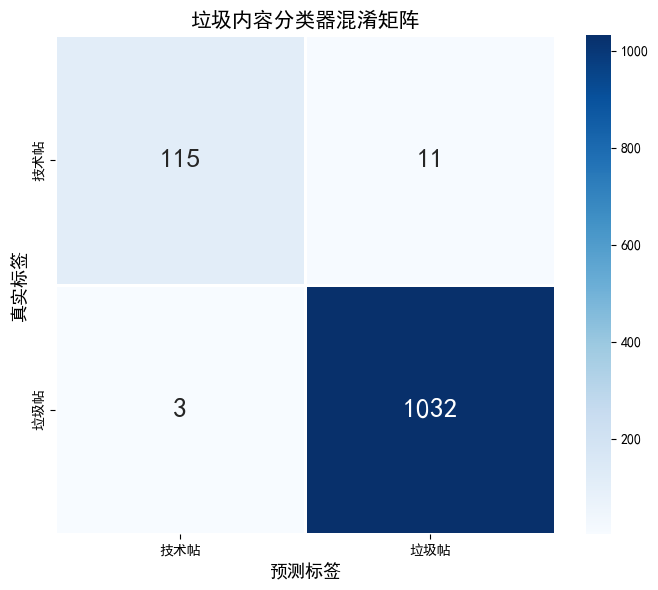

In [ ]:
# ── 图5：垃圾分类器混淆矩阵（重新生成高清版）──
test_texts = test_df["processed_text"].fillna("").astype(str)
X_test = vectorizer.transform(test_texts)
y_test = test_df["is_junk"].astype(int)
y_pred = junk_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
target_names = ["技术帖", "垃圾帖"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_names, yticklabels=target_names,
    ax=ax, annot_kws={"size": 20},
    linewidths=1, linecolor="white",
)
ax.set_title("垃圾内容分类器混淆矩阵", fontsize=15)
ax.set_xlabel("预测标签", fontsize=13)
ax.set_ylabel("真实标签", fontsize=13)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / "junk_confusion_matrix_hd.png"), dpi=200)
print("图5 混淆矩阵 ✓")
plt.show()

图6 数据集组成 ✓


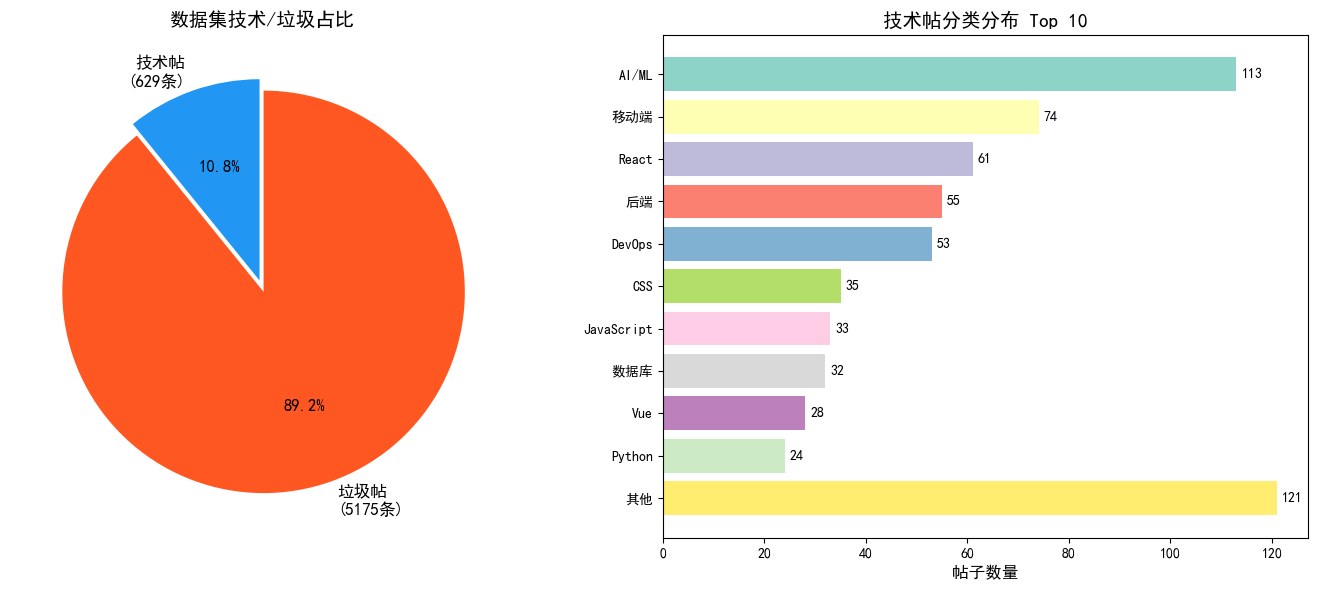

In [ ]:
# ── 图6：数据集组成饼图 ──
total_df = pd.concat([train_df, test_df], ignore_index=True)
tech_total = (total_df["is_junk"] == 0).sum()
junk_total = (total_df["is_junk"] == 1).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：技术/垃圾比例
axes[0].pie(
    [tech_total, junk_total],
    labels=[f"技术帖\n({tech_total}条)", f"垃圾帖\n({junk_total}条)"],
    colors=["#2196F3", "#FF5722"],
    autopct="%1.1f%%",
    textprops={"fontsize": 12},
    startangle=90,
    explode=(0.03, 0.03),
)
axes[0].set_title("数据集技术/垃圾占比", fontsize=14)

# 右：技术帖分类分布
tech_cats = total_df[total_df["is_junk"] == 0]["category"].value_counts()
top_cats = tech_cats.head(10)
other_count = tech_cats.iloc[10:].sum() if len(tech_cats) > 10 else 0
if other_count > 0:
    top_cats["其他"] = other_count

axes[1].barh(range(len(top_cats)), top_cats.values, color=plt.cm.Set3(np.linspace(0, 1, len(top_cats))))
axes[1].set_yticks(range(len(top_cats)))
axes[1].set_yticklabels(top_cats.index, fontsize=10)
axes[1].set_xlabel("帖子数量", fontsize=12)
axes[1].set_title("技术帖分类分布 Top 10", fontsize=14)
axes[1].invert_yaxis()
for i, v in enumerate(top_cats.values):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=10)

plt.tight_layout()
fig.savefig(str(FIGURES_DIR / "dataset_composition.png"), dpi=200)
print("图6 数据集组成 ✓")
plt.show()

In [ ]:
# 聚类指标
sil = silhouette_score(X_train, train_clusters)
ch = calinski_harabasz_score(X_train.toarray(), train_clusters)
db = davies_bouldin_score(X_train.toarray(), train_clusters)

# 分类指标
clf_report = classification_report(y_test, y_pred, output_dict=True)
accuracy = clf_report["accuracy"]
tech_precision = clf_report["0"]["precision"]
tech_recall = clf_report["0"]["recall"]
tech_f1 = clf_report["0"]["f1-score"]
junk_precision = clf_report["1"]["precision"]
junk_recall = clf_report["1"]["recall"]
junk_f1 = clf_report["1"]["f1-score"]

print("=" * 60)
print("模型评估指标汇总")
print("=" * 60)

print(f"\n【聚类模型 K-Means (K={kmeans.n_clusters})】")
print(f"  Silhouette Score:       {sil:.4f}")
print(f"  Calinski-Harabasz:      {ch:.2f}")
print(f"  Davies-Bouldin:         {db:.4f}")
print(f"  WCSS (Inertia):         {kmeans.inertia_:.2f}")

clf_name = type(junk_clf).__name__
print(f"\n【垃圾分类器 {clf_name}】")
print(f"  总体准确率:              {accuracy:.4f}")
print(f"  技术帖 Precision:        {tech_precision:.4f}")
print(f"  技术帖 Recall:           {tech_recall:.4f}")
print(f"  技术帖 F1:               {tech_f1:.4f}")
print(f"  垃圾帖 Precision:        {junk_precision:.4f}")
print(f"  垃圾帖 Recall:           {junk_recall:.4f}")
print(f"  垃圾帖 F1:               {junk_f1:.4f}")

print(f"\n【数据集规模】")
print(f"  总样本数:                {len(total_df)}")
print(f"  训练集:                  {len(train_df)}")
print(f"  测试集:                  {len(test_df)}")
print(f"  技术帖:                  {tech_total}")
print(f"  垃圾帖:                  {junk_total}")
print(f"  TF-IDF 特征维度:         {X_train.shape[1]}")
print("=" * 60)

模型评估指标汇总

【聚类模型 K-Means (K=10)】
  Silhouette Score:       0.0157
  Calinski-Harabasz:      16.97
  Davies-Bouldin:         7.7068
  WCSS (Inertia):         5817.48

【垃圾分类器 MultinomialNB】
  总体准确率:              0.9879
  技术帖 Precision:        0.9746
  技术帖 Recall:           0.9127
  技术帖 F1:               0.9426
  垃圾帖 Precision:        0.9895
  垃圾帖 Recall:           0.9971
  垃圾帖 F1:               0.9933

【数据集规模】
  总样本数:                5804
  训练集:                  6181
  测试集:                  1546
  技术帖:                  629
  垃圾帖:                  5175
  TF-IDF 特征维度:         5000


In [ ]:
# 列出所有已生成的图表
print("论文图表文件清单:")
print("=" * 60)
figures_dir = str(FIGURES_DIR)
if os.path.exists(figures_dir):
    files = sorted(os.listdir(figures_dir))
    for f in files:
        if f.endswith(".png"):
            fpath = os.path.join(figures_dir, f)
            size_kb = os.path.getsize(fpath) / 1024
            print(f"  {f:<40s} {size_kb:>8.1f} KB")
    print(f"\n共 {len([f for f in files if f.endswith('.png')])} 张图表")
    print(f"目录: {figures_dir}")
else:
    print(f"目录不存在: {figures_dir}")

论文图表文件清单:
  category_vs_cluster.png                     140.5 KB
  cluster_distribution.png                     86.1 KB
  clustering_metrics.png                      183.2 KB
  dataset_composition.png                     129.8 KB
  elbow_method.png                            100.7 KB
  junk_confusion_matrix.png                    85.3 KB
  junk_confusion_matrix_hd.png                 68.3 KB
  kmeans_pca.png                              236.2 KB
  kmeans_tsne.png                             297.3 KB
  pca_dual_view.png                           166.8 KB
  tfidf_heatmap.png                           154.4 KB
  tsne_dual_view.png                          789.4 KB

共 12 张图表
目录: D:\code-hub\ml-service\outputs\figures
